## EDA & preprocessing

В данном ноутбуке производится разведочный анализ данных, предобработка данных и констурирование новых признаков.



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from src.utils import get_project_root

In [3]:
PROJECT_ROOT = get_project_root()
DATA_PATH = PROJECT_ROOT / "data"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts" / "EDA"

In [4]:
df = df = pd.read_csv(DATA_PATH/"raw"/"train.csv")

In [5]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df.shape

(10886, 12)

In [7]:
df.columns.tolist()

['datetime',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'casual',
 'registered',
 'count']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


Некоторые признаки представлены числами, однако по своей природе являются категориальными. Например, признаки season и weather кодируют категории, а не непрерывные числовые значения.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [10]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

Пропущенных значений и дублирующихся строк нет.

In [12]:
df[(df['casual'] + df['registered']) == df['count']].shape

(10886, 12)

Можно заметить, что таргет ("count") получается из суммы "casual" + "registered", для избежания data leakage при обучении моделей нужно сразу удалить эти две колонки.

In [13]:
df = df.drop(columns=['casual', 'registered'])

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1


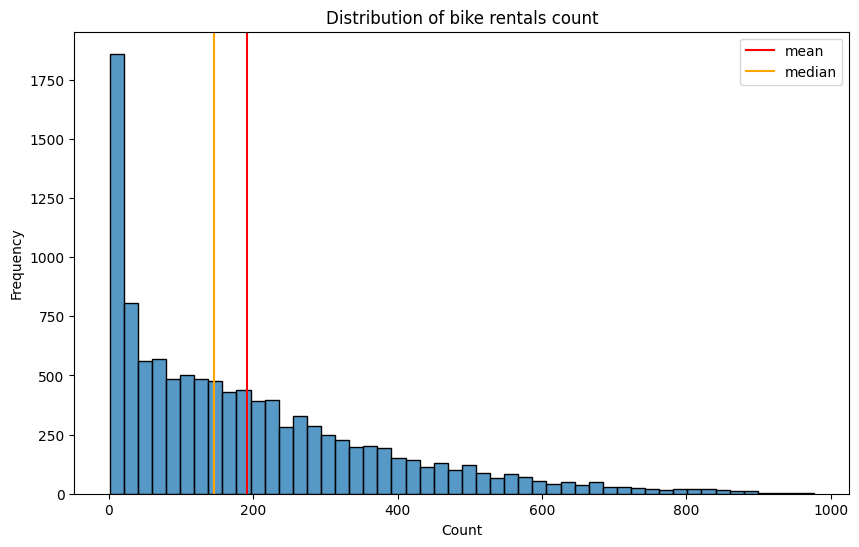

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(df["count"], bins=50)

plt.axvline(df['count'].mean(), c='red', label='mean')
plt.axvline(df['count'].median(), c='orange', label='median')

plt.title("Distribution of bike rentals count")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.legend()

plt.savefig(ARTIFACTS_PATH/"distribution_of_bike_rentals_count.png")
plt.show()

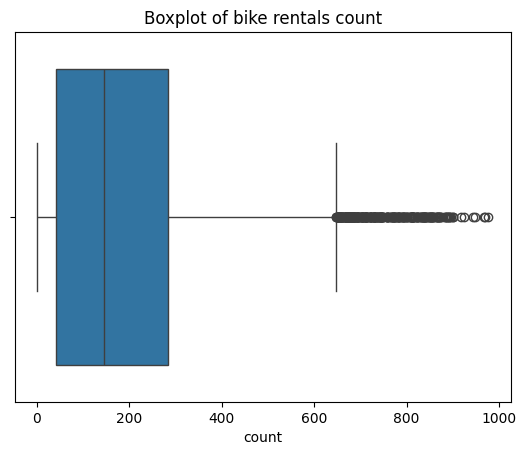

In [15]:
sns.boxplot(x=df["count"])

plt.title("Boxplot of bike rentals count")

plt.savefig(ARTIFACTS_PATH/"boxplot_of_bike rentals_count.png")
plt.show()

Распределение целевой переменной count имеет выраженную правостороннюю асимметрию: большинство наблюдений соответствует низкому или среднему спросу, тогда как высокие значения встречаются значительно реже.

Boxplot также показывает наличие большого количества экстремальных значений. Однако для данной задачи они не рассматриваются как ошибки данных, поскольку пики спроса являются естественной частью поведения пользователей bike-sharing сервиса.

Таким образом, удаление выбросов на этапе preprocessing не выполняется.

In [16]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,weekday,month,year
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16,0,5,1,2011
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40,1,5,1,2011
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32,2,5,1,2011
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13,3,5,1,2011
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1,4,5,1,2011


In [17]:
column_names = ['datetime',
                'hour', 
                'weekday', 
                'month', 
                'year', 
                'season', 
                'holiday', 
                'workingday', 
                'weather', 
                'temp', 
                'atemp',
                'humidity', 
                'windspeed', 
                'count']

df = df.reindex(columns=column_names)

df.head()

,datetime,hour,weekday,month,year,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,0,5,1,2011,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,5,1,2011,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,2,5,1,2011,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,3,5,1,2011,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,4,5,1,2011,1,0,0,1,9.84,14.395,75,0.0,1


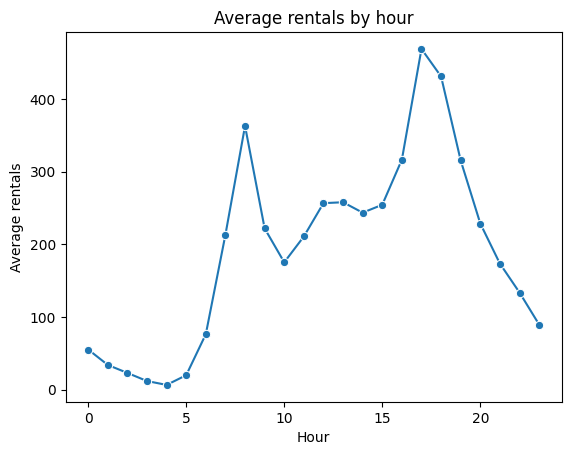

In [18]:
hourly_mean = df.groupby("hour")["count"].mean()

sns.lineplot(
    x=hourly_mean.index,
    y=hourly_mean.values,
    marker='o'
)

plt.title("Average rentals by hour")
plt.xlabel("Hour")
plt.ylabel("Average rentals")

plt.savefig(ARTIFACTS_PATH/"average_rentals.png")
plt.show()

Графику среднего количества аренд по часам показывет ярко выраженные временные интервалы, в которых наблюдается пик спроса:
- утренний пик около 8:00;
- вечерний пик около 17:00-18:00

Такое поведение соответвуюет сценарию использования bike-sharing сервиса, когда пользователи арендут велосипеды для поездок на работу/учебу и обратно

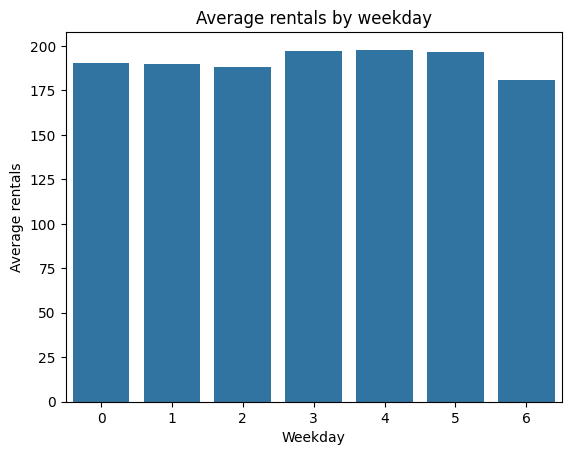

In [19]:
weekday_mean = df.groupby("weekday")["count"].mean()

sns.barplot(
    x=weekday_mean.index,
    y=weekday_mean.values
)

plt.title("Average rentals by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average rentals")

plt.savefig(ARTIFACTS_PATH/"average_rentals_by_weekday.png")
plt.show()

График среднего количества аренд по дням недели показывает, что различия между днями выражены значительно слабее, чем различия между часами суток. Тем не менее можно заметить небольшое увеличение спроса в середине недели и снижение спроса в конце недели. Значит день недели может быть полезен в комбинации с другими признаками

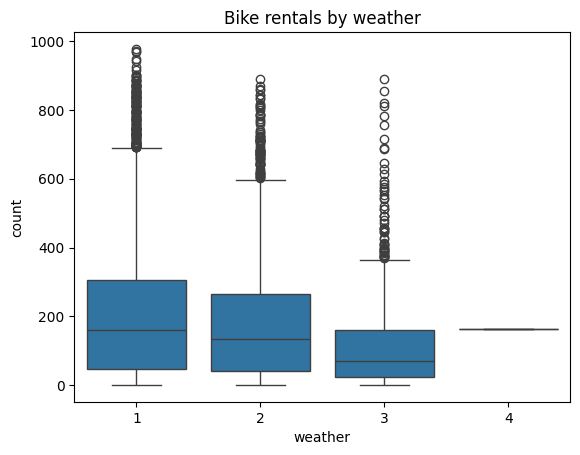

In [20]:
sns.boxplot(
    data=df,
    x="weather",
    y="count"
)

plt.title("Bike rentals by weather")

plt.savefig(ARTIFACTS_PATH/"bike_rentals_by_weather.png")
plt.show()

График распределения количества аренд по погодным условиям показывает существование влияния погоды на спрос. При хороших погодных условиях наблюдается наибольший медианный спрос, а также самые высокие пиковые значения количества аренд.

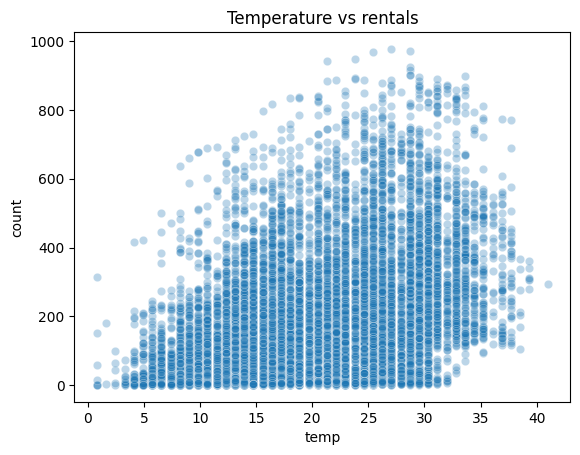

In [21]:
sns.scatterplot(
    data=df,
    x="temp",
    y="count",
    alpha=0.3
)

plt.title("Temperature vs rentals")

plt.savefig(ARTIFACTS_PATH/"temperature_vs_rentals.png")
plt.show()

Scatterplot показывает выраженную зависимость между температурой и количеством аренд велосипедов. Наибольший спрос наблюдается при умеренно высокой температуре (примерно 20–30°C), что соответствует наиболее комфортным условиям для использования bike-sharing сервиса. При этом зависимость не является строго линейной: после определенного значения температуры верхняя граница спроса начинает снижаться, что может указывать на снижение активности пользователей в слишком жаркую погоду. Также заметен значительный разброс значений target при одинаковой температуре, что говорит о влиянии дополнительных факторов, таких как время суток и погодные условия.

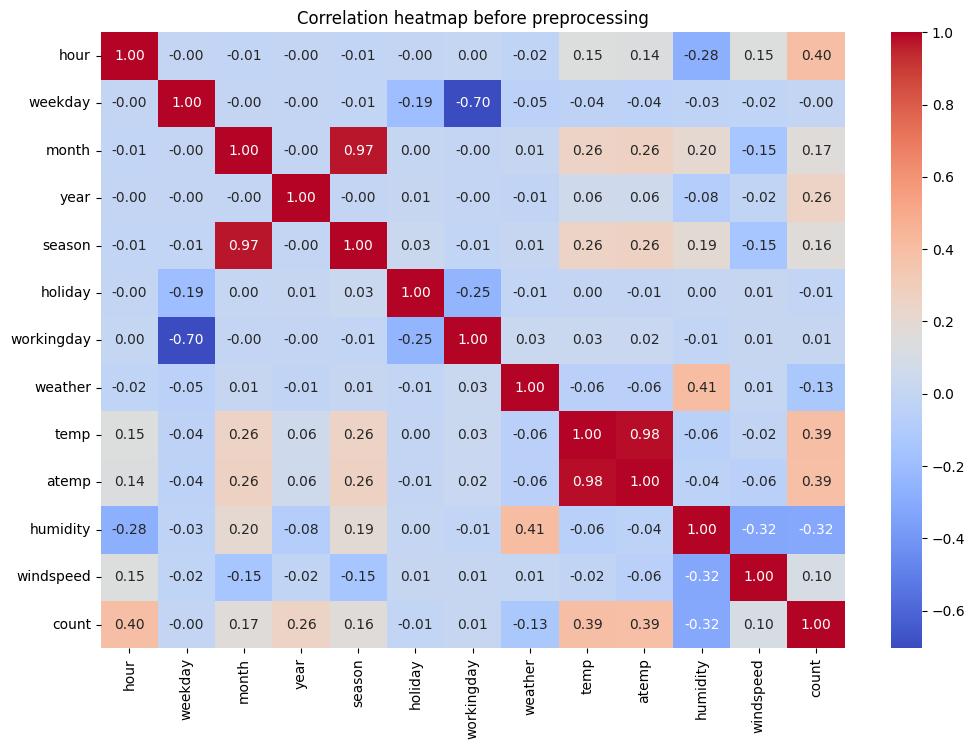

In [22]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=True,
    fmt='.2f'
)

plt.title("Correlation heatmap before preprocessing")

plt.savefig(ARTIFACTS_PATH/"correlation_heatmap_before_preprocessing.png")
plt.show()

Матрица корреляций подтверждает результаты предыдущего анализа данных. Наиболее сильная линейная связь с целевой переменной наблюдается у признаков hour, temp и atemp, что соответствует выявленным временным и погодным паттернам спроса.

Также можно заметить очень высокую корреляцию между признаками temp и atemp, а также между month и season. Это означает, что данные признаки содержат схожую информацию и дают мультиколлинеарность. Сразу удалять их не будем, чтобы была возможность провести эксперименты с разными признаками.

При этом некоторые признаки, например weekday и weather, имеют слабую линейную корреляцию с target, однако результаты EDA показывают, что они все равно могут быть полезны для моделей за счет нелинейных зависимостей и взаимодействий между признаками.

In [23]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

df = df.drop(columns=['hour', 'weekday', 'datetime'])

df.head()

,month,year,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour_sin,hour_cos,weekday_sin,weekday_cos
0,1,2011,1,0,0,1,9.84,14.395,81,0.0,16,0.000000,1.000000,-0.974928,-0.222521
1,1,2011,1,0,0,1,9.02,13.635,80,0.0,40,0.258819,0.965926,-0.974928,-0.222521
2,1,2011,1,0,0,1,9.02,13.635,80,0.0,32,0.500000,0.866025,-0.974928,-0.222521
3,1,2011,1,0,0,1,9.84,14.395,75,0.0,13,0.707107,0.707107,-0.974928,-0.222521
4,1,2011,1,0,0,1,9.84,14.395,75,0.0,1,0.866025,0.500000,-0.974928,-0.222521


Часы и дни недели - цикличные признаки. Для модели "00:00" и "23:00" могут казаться очень далекими друг от друга, хотя в реальности их разделяет всего один час. Чтобы сохранить эту циклическую природу времени, сутки можно представить в виде окружности и закодировать часы с помощью функций синуса и косинуса. Тогда близкие моменты времени будут иметь близкие значения признаков. Аналогичный подход применяется и для дней недели, поскольку после воскресенья снова следует понедельник.

Чтобы обеспечить честные условия экспериметнов при сравнии разных моделей, удалим исходные столбцы для часов и дней недели после кодирования, потому что их способ представления циклических признаков влияет на качество линейных моделей гораздно сильнее, чем на качество ансамблевых.

Также удалим колонку "datetime", потому что она не нужна для обучения моделей, а нужна для выделения новых признаков

In [24]:
new_columns = ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos']
column_names = column_names[3:]

column_names_final = new_columns + column_names

column_names_final

['hour_sin',
 'hour_cos',
 'weekday_sin',
 'weekday_cos',
 'month',
 'year',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'count']

In [25]:
df = df.reindex(columns=column_names_final)

df.head()

,hour_sin,hour_cos,weekday_sin,weekday_cos,month,year,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,0.000000,1.000000,-0.974928,-0.222521,1,2011,1,0,0,1,9.84,14.395,81,0.0,16
1,0.258819,0.965926,-0.974928,-0.222521,1,2011,1,0,0,1,9.02,13.635,80,0.0,40
2,0.500000,0.866025,-0.974928,-0.222521,1,2011,1,0,0,1,9.02,13.635,80,0.0,32
3,0.707107,0.707107,-0.974928,-0.222521,1,2011,1,0,0,1,9.84,14.395,75,0.0,13
4,0.866025,0.500000,-0.974928,-0.222521,1,2011,1,0,0,1,9.84,14.395,75,0.0,1


In [26]:
df.sample(10)

,hour_sin,hour_cos,weekday_sin,weekday_cos,month,year,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
2692,5.000000e-01,0.866025,-0.433884,-0.900969,7,2011,3,0,1,1,25.42,30.305,69,0.0000,13
8394,7.071068e-01,0.707107,0.974928,-0.222521,7,2012,3,0,1,1,26.24,28.790,89,8.9981,5
6955,7.071068e-01,0.707107,-0.781831,0.623490,4,2012,2,0,0,1,17.22,21.210,26,8.9981,26
5880,9.659258e-01,0.258819,0.974928,-0.222521,2,2012,1,0,1,1,16.40,20.455,50,11.0014,18
9935,8.660254e-01,-0.500000,0.433884,-0.900969,10,2012,4,0,1,1,18.86,22.725,82,16.9979,834
2949,-9.659258e-01,0.258819,0.000000,1.000000,7,2011,3,0,1,1,34.44,41.665,59,22.0028,373
197,1.224647e-16,-1.000000,-0.781831,0.623490,1,2011,1,0,0,1,7.38,6.820,37,30.0026,83
4665,2.588190e-01,-0.965926,0.000000,1.000000,11,2011,4,0,1,1,17.22,21.210,77,7.0015,128
6355,2.588190e-01,0.965926,-0.433884,-0.900969,3,2012,1,0,1,1,13.94,15.910,49,15.0013,20
1103,-5.000000e-01,-0.866025,0.433884,-0.900969,3,2011,1,0,1,3,18.04,21.970,0,19.9995,12


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_sin     10886 non-null  float64
 1   hour_cos     10886 non-null  float64
 2   weekday_sin  10886 non-null  float64
 3   weekday_cos  10886 non-null  float64
 4   month        10886 non-null  int32  
 5   year         10886 non-null  int32  
 6   season       10886 non-null  int64  
 7   holiday      10886 non-null  int64  
 8   workingday   10886 non-null  int64  
 9   weather      10886 non-null  int64  
 10  temp         10886 non-null  float64
 11  atemp        10886 non-null  float64
 12  humidity     10886 non-null  int64  
 13  windspeed    10886 non-null  float64
 14  count        10886 non-null  int64  
dtypes: float64(7), int32(2), int64(6)
memory usage: 1.2 MB


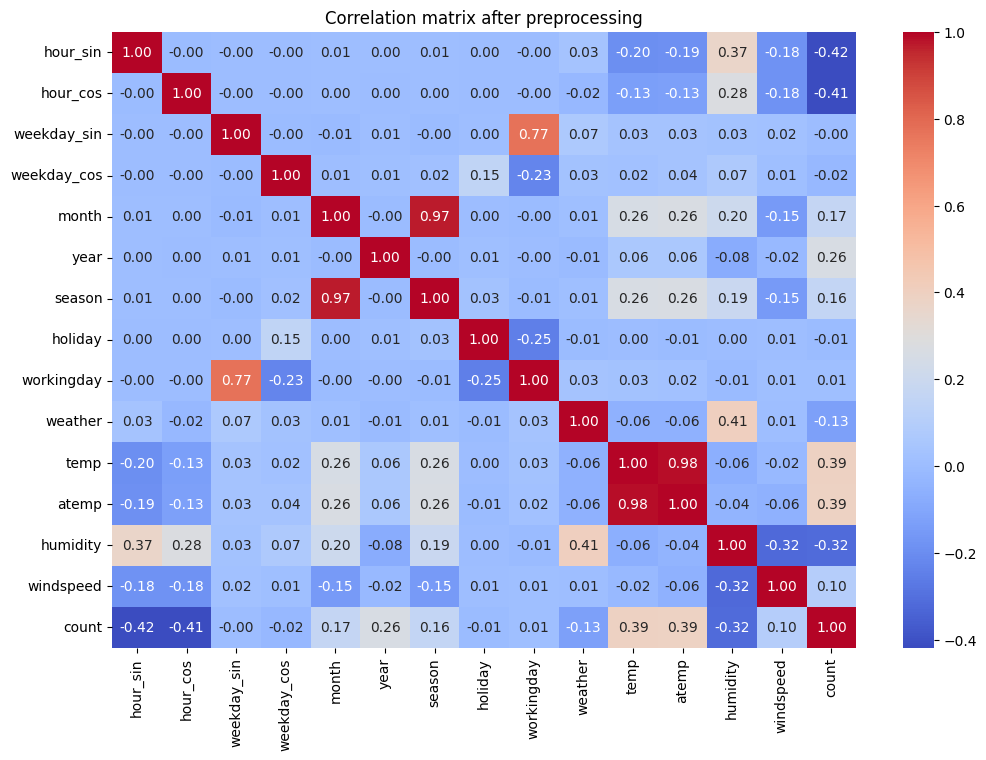

In [28]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation matrix after preprocessing")

plt.savefig(ARTIFACTS_PATH/"correlation_matrix_after_preprocessing.png")
plt.show()

Финальная матрица корреляций отражает результат preprocessing и feature engineering.

После кодирования временные признаки стали представлены через синус и косинус, что позволило сохранить циклическую структуру времени суток и дней недели. При этом признаки "hour_sin" и "hour_cos" сохраняют заметную связь с целевой переменной, что подтверждает важность времени суток для прогнозирования спроса.

Также можно заметить сохранения мультиколлинеарности некоторых признаков.

При этом некоторые признаки, например weekday и weather, имеют слабую линейную корреляцию с target, однако результаты EDA показывают, что они все равно могут быть полезны для моделей за счет нелинейных зависимостей и взаимодействий между признаками.

### Итоги

В ходе разведочного анализа данных были изучены основные закономерности, влияющие на спрос bike-sharing сервиса.

Анализ целевой переменной показал наличие выраженной правосторонней асимметрии распределения количества аренд. Большинство наблюдений соответствуют низкому или среднему спросу, но при этом экстремальные значения не рассматриваются как ошибки, потому что пик спроса соответсвует паттерну поведения пользователей.

Временные признаки оказались одними из наиболее информативных факторов. График среднего количества аренд по часам показал два ярко выраженных пика спроса — утром и вечером, что хорошо соответствует сценарию использования сервиса. Также было выявлено влияние дней недели, хотя оно выражено слабее.

Анализ погодных условий и температуры подтвердил, что комфортная погода положительно влияет на спрос, тогда как ухудшение погодных условий снижает активность пользователей.

Была выялвения мультиколлинеарность некоторых признаков. Однако такие признаки не были удалены, т.к. они могут поднять качество на некоторых моделях.

В ходе preprocessing были выполнены:
- удаление "casual" и "registered", так как именно из их суммы складывается таргет;
- извлечение временных признаков из "datetime";
- кодирование циклических временных признаков "hour" и "weekday";
- удаление исходных циклических признаков после кодирования;
- удаление "datetime"

В результате был сформирован итоговый набор признаков, пригодный для дальнейшего обучения и сравнения различных моделей.